In [7]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import TwoSlopeNorm 
from scipy.optimize import curve_fit
import seaborn as sns
import pandas as pd
import parana_theme as tema
tema.aplicar_tema()

In [2]:
K_VALUES = [0.5, 0.971635, 1.5, 6.47] 
H5_FILENAME = '../dat/displacement_p.h5'
OUTPUT_PDF = '../plots/standard_map_displacement.pdf'

In [ ]:
df = pd.DataFrame()
for k_val in K_VALUES:
    with h5py.File(H5_FILENAME, 'r') as f:
        dset_name = f"K_{k_val:.6f}"
        data = f[dset_name][:]
    data = pd.DataFrame(np.reshape(data, (-1))).transpose().melt(var_name='Part', value_name=f'K_{k_val:.6f}')
    df = pd.concat([df, data], axis=1)
   #df = pd.DataFrame(data).transpose()


SyntaxError: invalid decimal literal (2065584633.py, line 7)

In [49]:
df

,Part,K_0.500000,Part,K_0.971635,Part,K_1.500000,Part,K_6.470000
0,0,0.000000,0,0.000000e+00,0,0.000000e+00,0,201.752682
1,1,-0.004135,1,-1.293299e-02,1,-5.198726e-03,1,2389.903365
2,2,0.002182,2,-2.265124e-02,2,-1.465886e-02,2,-341.856258
3,3,-0.009699,3,-1.986314e-02,3,-3.149294e-02,3,-9.326259
4,4,-0.054780,4,-9.007559e-04,4,-5.074383e-02,4,-708.929848
...,...,...,...,...,...,...,...,...
1048571,1048571,0.054780,1048571,9.007559e-04,1048571,5.074383e-02,1048571,-88.704540
1048572,1048572,0.009699,1048572,1.986314e-02,1048572,3.149294e-02,1048572,-563.372602
1048573,1048573,-0.002182,1048573,2.265124e-02,1048573,1.465886e-02,1048573,129.724733
1048574,1048574,0.004135,1048574,1.293299e-02,1048574,5.198726e-03,1048574,-77.316525


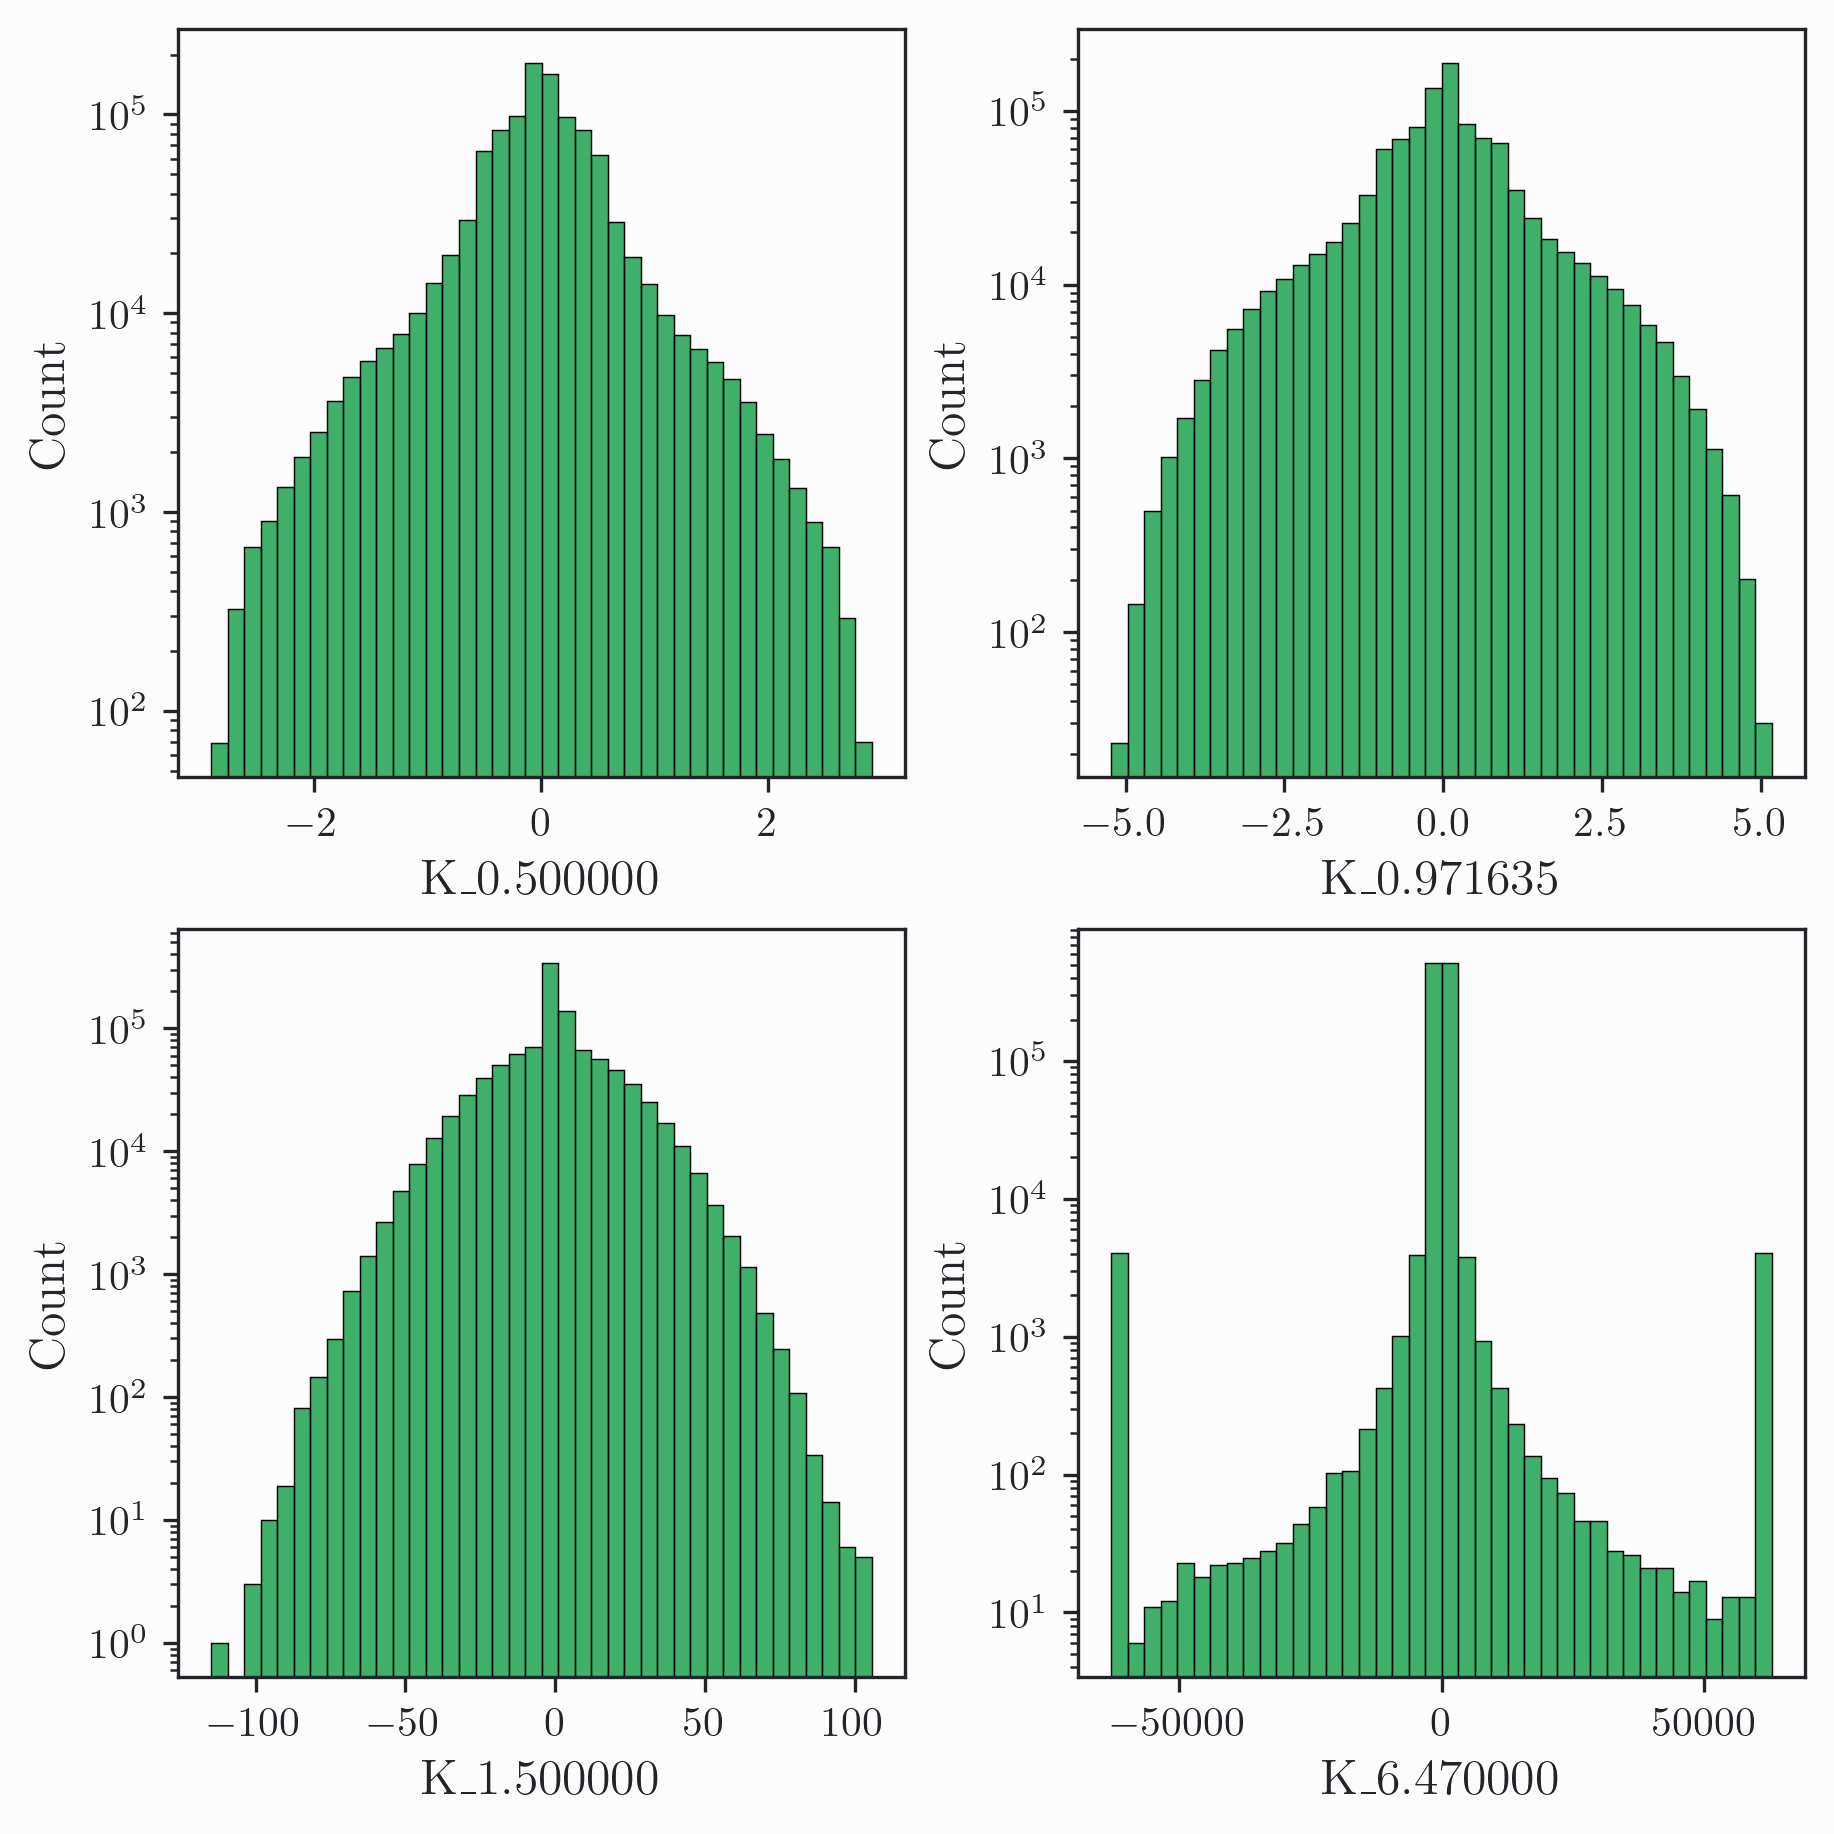

In [59]:
fig, ax = plt.subplot_mosaic([['A', 'B'], ['C', 'D']], figsize=(6, 6), layout='constrained')
sns.histplot(data=df["K_0.500000"], ax=ax["A"],bins=40)
sns.histplot(data=df["K_0.971635"], ax=ax["B"],bins=40)
sns.histplot(data=df["K_1.500000"], ax=ax["C"],bins=40)
sns.histplot(data=df["K_6.470000"], ax=ax["D"],bins=40)
ax["A"].set_yscale('log')  
ax["B"].set_yscale('log')  
ax["C"].set_yscale('log')
ax["D"].set_yscale('log')  
